# **Exploratory Data Analysis:**

This notebook explores the different features extracted for the 24 hour baseline dataset.

## **Setup:**

In [1]:
# Import dataset:
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = Path("/Users/gloriaduo/Documents/SJSU/SPRING 2026/CS 133 (Data Visualization)/Project/Predicting-Patient-Mortality/derived_results")

BASELINE_DATASET_PARQUET = DATA_DIR / "baseline_dataset.parquet"

baseline_df = pd.read_parquet(BASELINE_DATASET_PARQUET)

In [2]:
# Preview dataset:
baseline_df.head()

,subject_id,hadm_id,stay_id,first_careunit,intime,outtime,admission_type,admission_location,insurance,language,...,mean_val_potassium,mean_val_sodium,mean_val_wbc,last_val_bilirubin,last_val_creatinine,last_val_lactate,last_val_platelets,last_val_potassium,last_val_sodium,last_val_wbc
0,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,EW EMER.,EMERGENCY ROOM,Medicare,English,...,4.400000,137.000,7.500000,NaN,0.9,NaN,199.0,4.4,137.0,7.5
1,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,EW EMER.,EMERGENCY ROOM,Private,Other,...,3.600000,138.000,19.000000,NaN,0.4,NaN,285.0,3.6,138.0,19.0
2,10001725,25563031,31205490,Medical/Surgical Intensive Care Unit (MICU/SICU),2110-04-11 15:52:22,2110-04-12 23:59:56,EW EMER.,PACU,Private,English,...,3.700000,139.000,18.550000,NaN,0.8,NaN,299.0,3.5,138.0,20.1
3,10001884,26184834,37510196,Medical Intensive Care Unit (MICU),2131-01-11 04:20:05,2131-01-20 08:27:30,OBSERVATION ADMIT,EMERGENCY ROOM,Medicare,English,...,4.033333,136.000,15.200000,0.2,1.0,1.1,149.0,4.2,138.0,12.0
4,10002013,23581541,39060235,Cardiac Vascular Intensive Care Unit (CVICU),2160-05-18 10:00:53,2160-05-19 17:33:33,SURGICAL SAME DAY ADMISSION,PHYSICIAN REFERRAL,Medicare,English,...,3.980000,137.625,18.766667,NaN,0.9,2.6,248.0,4.5,136.0,17.9


In [3]:
# View columns:
baseline_df.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'intime',
       'outtime', 'admission_type', 'admission_location', 'insurance',
       'language', 'marital_status', 'race_grouped', 'is_male', 'age',
       'ICU_mortality', 'ICU_endtime', 'ICU_time_to_event_hours',
       'window_24h_end', 'min_val_heart_rate', 'min_val_map',
       'min_val_resp_rate', 'min_val_spo2', 'min_val_temperature',
       'max_val_heart_rate', 'max_val_map', 'max_val_resp_rate',
       'max_val_spo2', 'max_val_temperature', 'mean_val_heart_rate',
       'mean_val_map', 'mean_val_resp_rate', 'mean_val_spo2',
       'mean_val_temperature', 'last_val_heart_rate', 'last_val_map',
       'last_val_resp_rate', 'last_val_spo2', 'last_val_temperature',
       'min_val_bilirubin', 'min_val_creatinine', 'min_val_lactate',
       'min_val_platelets', 'min_val_potassium', 'min_val_sodium',
       'min_val_wbc', 'max_val_bilirubin', 'max_val_creatinine',
       'max_val_lactate', 'max_val_platelets', 'max_val

In [4]:
# View missing values + data types:
baseline_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 74583 entries, 0 to 74582
Data columns (total 66 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   subject_id               74583 non-null  int32         
 1   hadm_id                  74583 non-null  int32         
 2   stay_id                  74583 non-null  int32         
 3   first_careunit           74583 non-null  str           
 4   intime                   74583 non-null  datetime64[us]
 5   outtime                  74583 non-null  datetime64[us]
 6   admission_type           74583 non-null  category      
 7   admission_location       74583 non-null  category      
 8   insurance                74583 non-null  category      
 9   language                 74583 non-null  category      
 10  marital_status           74583 non-null  category      
 11  race_grouped             74583 non-null  category      
 12  is_male                  74583 non-null  bo

## **Feature Exploration:**

The static features in this dataset worth examining are:

**Categorical:**
  - admission_type 
  - admission_location
  - insurance
  - language
  - marital_status
  - race_grouped
  - is_male
  - ICU_mortality

**Numerical:**
  - age
  - ICU_time_to_event_hours

### **Univariate Exploration:**

Since we have so many aggregation values, we'll skip over those in this section and evaluate them against our outcome in a later section.

In [5]:
# Separate categorical from numerical features:
categorical_features = ["admission_type", "admission_location", "insurance", "language", "marital_status", "race_grouped", "is_male", "ICU_mortality"]
numerical_features = ["age", "ICU_time_to_event_hours"]

#### **Categorical Features:**

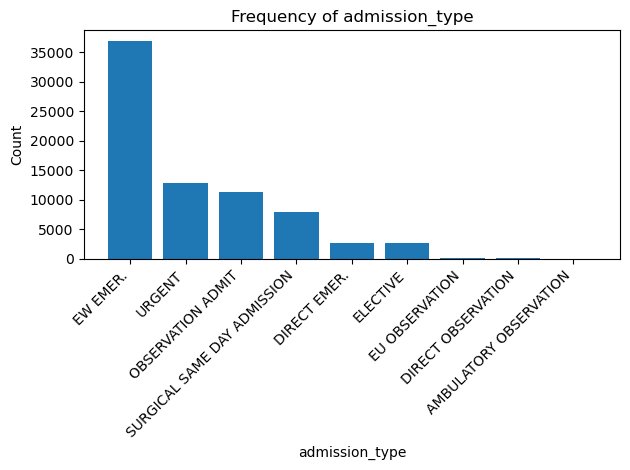

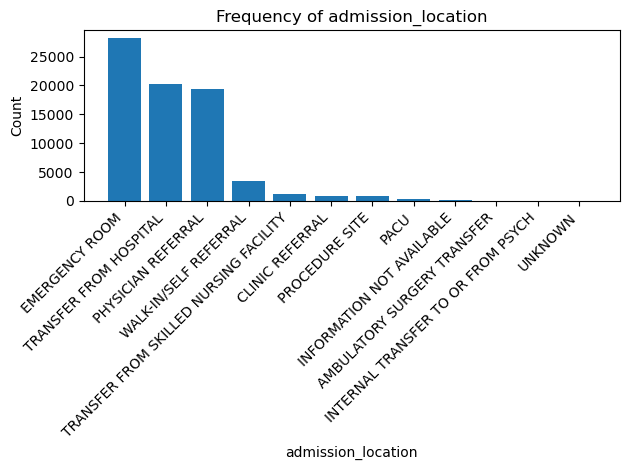

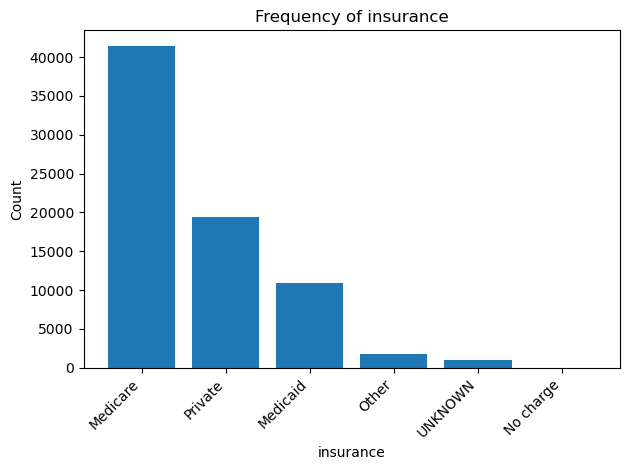

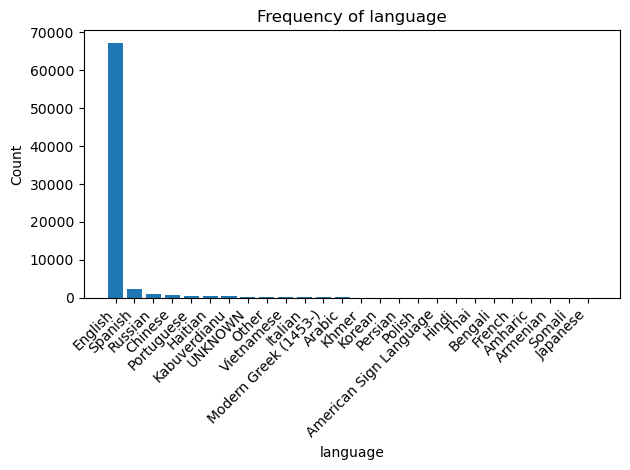

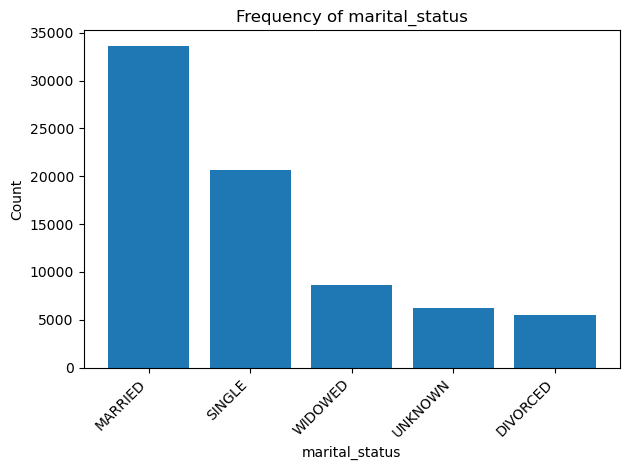

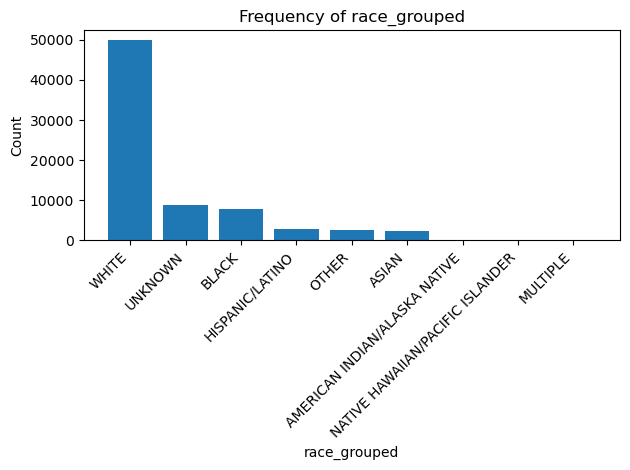

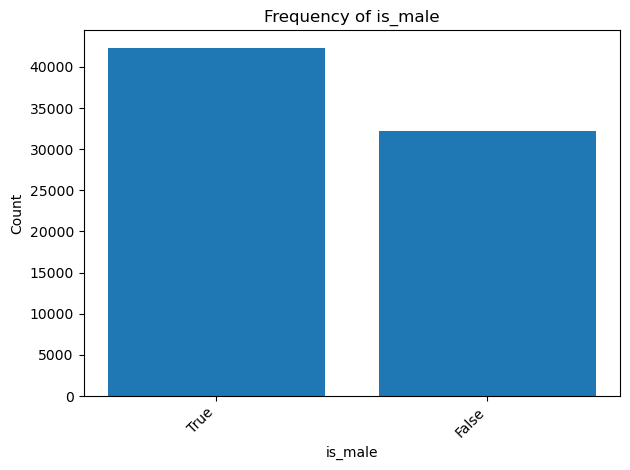

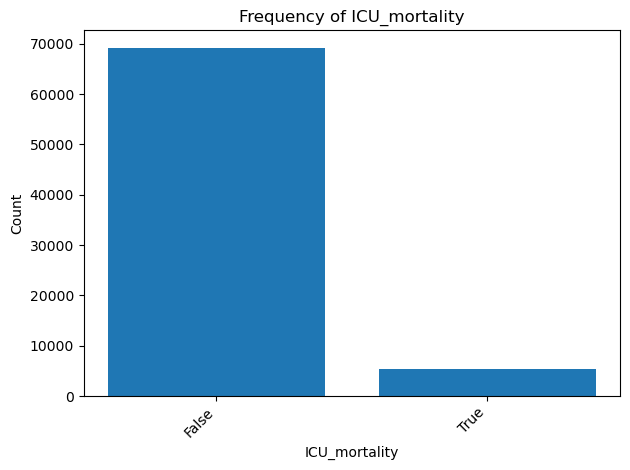

In [6]:
# Plotting categorical features:
for col in categorical_features:
    counts = baseline_df[col].value_counts(dropna=False)
    plt.figure()
    plt.bar(range(len(counts)), counts.values)
    plt.xticks(range(len(counts)), counts.index, rotation=45, ha="right")
    plt.title(f"Frequency of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

**Observations:**

**admission_type:**
  -  Most patients are admitted via emergency department transfer (EW Emer.)
  -  As expected, patients who are first placed under observation first do not make up a significant portion of the ICU cohort. This patients tend to be lower acuity.
  -  There are a significant number of category labels that are very rare. *We can consider grouping these rare categories to reduce dimensionality.*

**admission_location:**
  - Similar to admission_type, the majority of patients who are admitted come straight from the emergency department.
  - This is followed by hospital transfers, then referrals.
  - There are a significant number of category labels that are very rare. *We can consider grouping these rare categories to reduce dimensionality.*

**insurance:**
  - Medicare dominates the insurance category. Something interesting to note: Medicare is reserved for Americans aged 65+ or those who have a disibility. This insurance is provided by the federal government to Americans who meet said criteria, REGARDLESS of income.
  - Medicaid is intended for low-income individuals and eligibility is determined based on an individual's financial resources. This program is jointly managed by the state and federal government, so eligibility varies by region.
  - Individuals with private insurance possibly have higher income/employment.
  - Medicare rates indicate that most of our cohort are elderly (which is also verifiable by looking at the age distribution).

**language:**
  - English speakers dominate the cohort. Considering that the primary language spoken by most people in America is English, non-English speaking patients may face barriers to communication. *We may want to consider splitting this group into English vs. non-English speaking patients.*

**marital_status:**
  - Though there appears to be imbalance in marital status, each group has significant representation, so we don't need to consider grouping again.
  - Generally speaking, if someone is married, we can expect them to have greater social support via their spouse. Do married individuals tend to have more positive outcomes (higher chance of survival)?
  - Widowed individuals are likely older in age.

**race_grouped:**
  - White individuals dominate the cohort. Although being white doesn't actually increase a person's biological advantage, it is commonly stated that white individuals may benefit from structural inequalities in the healthcare system + systemic unfairness in general (i.e. access to better paying jobs, education, etc.). The implication of this imbalance is that our model will mostly learn on white patients.
  - Some groups are majorly underrepresented, and we can choose to bin them together as these are very rare categories.
  - We should consider keeping the "Unknown" label because this might represent missing information, real-world uncertainty, or documentation gaps (better to not assume here).

**is_male:**
  - Though men are better represented by women, the difference in categorical representation is not extreme. We can leave this alone.
  - We should check to see if the outcome differs based on sex.

**ICU_mortality:**
  - ICU mortality rates are quite low, and this class imbalance means that we will have to apply techniques later on to address this class imbalance so that our model gets a fair shot at learning.
  - We can first find a true baseline (just using the data as is), then we can move on to testing different class weights and comparing metrics (focusing on PR-AUC & recall). We can also use threshold tuning, noting that it is better to emphasize mortality in clinical settings (we'd rather err on the side of caution and classify a patient as high risk).
  - **I do not recommend using SMOTE** because our data uses mixed sources of information (numerical + categorical), contains small minority classes, and clinical data has very complex feature relations that are very difficult to represent (SMOTE interpolates between nearby samples in feature space).

#### **Numerical Features:**

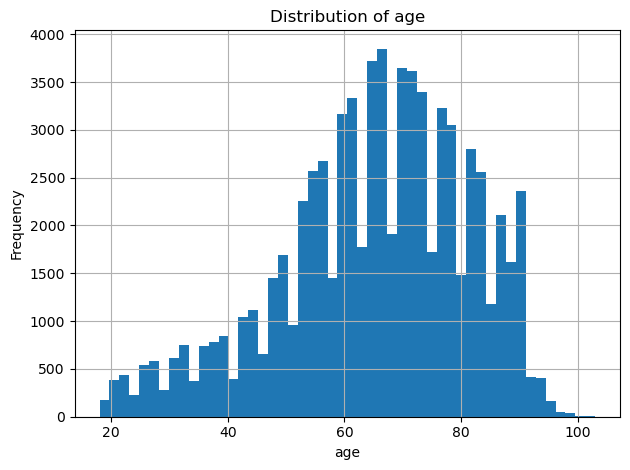

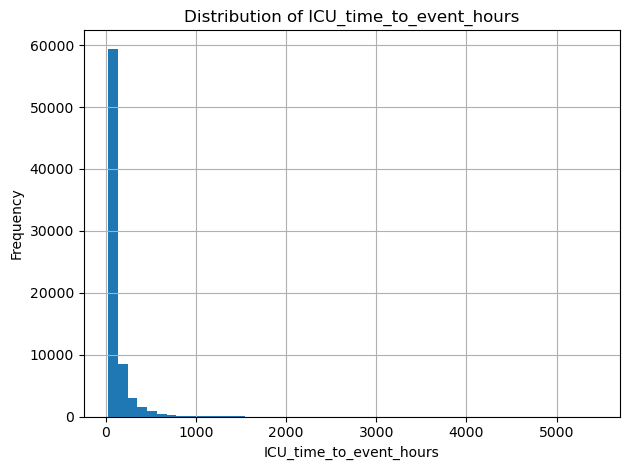

In [7]:
# Plotting numerical features:
for col in numerical_features:
    plt.figure()
    baseline_df[col].hist(bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

I noticed that there's some pretty heavy skewing for the ICU_time_to_event_hours feature. Let's use a log plot instead.

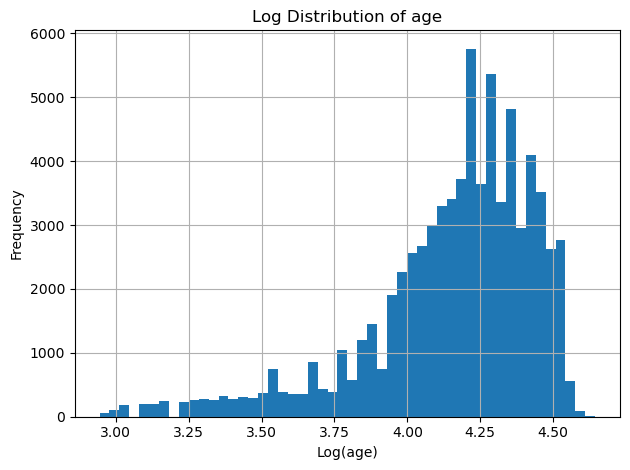

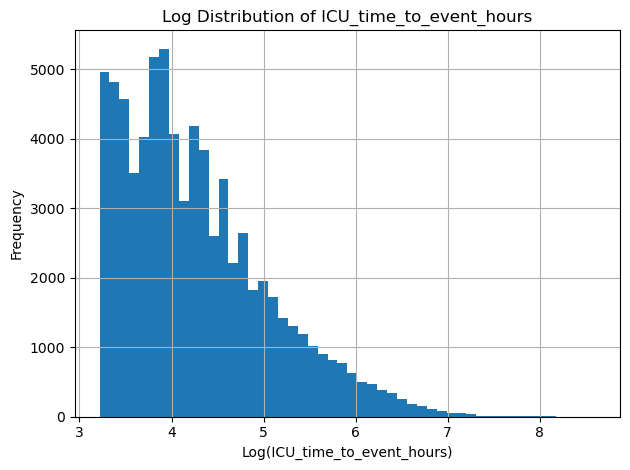

In [8]:
# Plotting numerical features using log scale:
import numpy as np

for col in numerical_features:
    if (baseline_df[col] > 0).all():
        plt.figure()
        np.log1p(baseline_df[col]).hist(bins=50)
        plt.title(f"Log Distribution of {col}")
        plt.xlabel(f"Log({col})")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

**Observations:**

**age:**
  - Most patients are middle-aged to elderly.
  - We should investigate the relationship between age and outcome.

**ICU_time_to_event_hours:**
  - Most patients who enter the ICU are not there for a very long time. This means that most outcomes happen EARLY.
  - Some patients do stay for an extended period, but this is much rarer.
  - This feature introduces data leakage if used directly -> just use this for binning.
  - We should compare this feature to outcome (we expect that people who die have shorter stays, survivors have longer stays).

### **Bivariate Features:**

For bivariate analysis, we'll plot relevant categorical and numerical features against the outcome to determine feature importance. Let's create a new dataframe that only contains our outcome and our feature variables.

In [9]:
# Create a new dataframe for bivariate analysis:
bivariate_df = baseline_df.copy()

In [10]:
# Define target/outcome feature:
target_col = "ICU_mortality"

In [11]:
# Drop identifiers + features that result in data leakage:
drop_cols = [
    "subject_id",
    "hadm_id",
    "stay_id",
    "intime",
    "outtime",
    "ICU_endtime",
    "ICU_time_to_event_hours",
    "window_24h_end",
]

bivariate_df.drop(columns=drop_cols, inplace=True)

In [12]:
# Simplify categorical variables (noted in univariate feature analysis):

# Admission Type (EMERGENCY, URGENT, OBSERVATION, ELECTIVE, SURGICAL, OTHER)
def group_admission_type(admission_type):
    admission_type = str(admission_type).strip().upper()

    if "EMER" in admission_type:
        return "EMERGENCY"
    elif "URGENT" in admission_type:
        return "URGENT"
    elif "OBSERVATION" in admission_type:
        return "OBSERVATION"
    elif "ELECTIVE" in admission_type:
        return "ELECTIVE"
    elif "SURGICAL SAME DAY" in admission_type:
        return "SURGICAL"
    else:
        return "OTHER"

bivariate_df["admission_type_grouped"] = bivariate_df["admission_type"].apply(group_admission_type)
bivariate_df.drop(columns="admission_type", inplace=True)

# Admission Location (EMERGENCY ROOM, TRANSFER, PHYSICIAN REFERRAL, CLINIC REFERRAL, PROCEDURE SURGERY, INTERNAL, UNKNOWN, OTHER):
def group_admission_location(admission_location):
    admission_location = str(admission_location).strip().upper()

    # Unplanned, high-acuity entry:
    if admission_location == "EMERGENCY ROOM":
        return "EMERGENCY"

    # Patient was examined before admission (usually lower-acuity & more stable):
    elif admission_location in [
        "PHYSICIAN REFERRAL",
        "CLINIC REFERRAL",
        "WALK-IN/SELF REFERRAL",
    ]:
        return "REFERRAL"

    # Transfers from external care centers (sick enough to warrant a transfer):
    elif "TRANSFER FROM" in admission_location:
        return "TRANSFER"

    # Admissions tied to procedures:
    elif (
        "PROCEDURE" in admission_location
        or "SURGERY" in admission_location
        or admission_location == "PACU"
    ):
        return "PROCEDURE"

    # Internal transfers:
    elif "INTERNAL" in admission_location:
        return "INTERNAL"

    # Unclear what happened:
    elif admission_location in ["UNKNOWN", "INFORMATION NOT AVAILABLE"]:
        return "UNKNOWN"
        
    # Other:
    else:
        return "OTHER"

bivariate_df["admission_location_grouped"] = bivariate_df["admission_location"].apply(group_admission_location)
bivariate_df.drop(columns="admission_location", inplace=True)

# Language (English-speaking vs. non-English-speaking vs. Unknown):
def group_language(language):
    language = str(language).strip().upper()
    
    if language == "ENGLISH":
        return "ENGLISH"
    elif language == "UNKNOWN":
        return "UNKNOWN"
    else:
        return "NON-ENGLISH"

bivariate_df["language_grouped"] = bivariate_df["language"].apply(group_language)
bivariate_df.drop(columns="language", inplace=True)

Test AUC: 0.8453

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.82      0.89     13840
           1       0.23      0.70      0.34      1077

    accuracy                           0.81     14917
   macro avg       0.60      0.76      0.61     14917
weighted avg       0.92      0.81      0.85     14917


Feature importances:
last_val_creatinine     0.076713
max_val_bilirubin       0.076436
last_val_lactate        0.066135
max_val_creatinine      0.050333
mean_val_resp_rate      0.048691
mean_val_bilirubin      0.038890
max_val_lactate         0.036674
min_val_spo2            0.034336
max_val_sodium          0.032194
mean_val_lactate        0.029166
last_val_sodium         0.025487
last_val_wbc            0.023690
last_val_spo2           0.023107
min_val_map             0.019902
mean_val_spo2           0.019712
min_val_bilirubin       0.019666
min_val_resp_rate       0.017179
last_val_heart_rate     0.016563
max_val_heart_ra

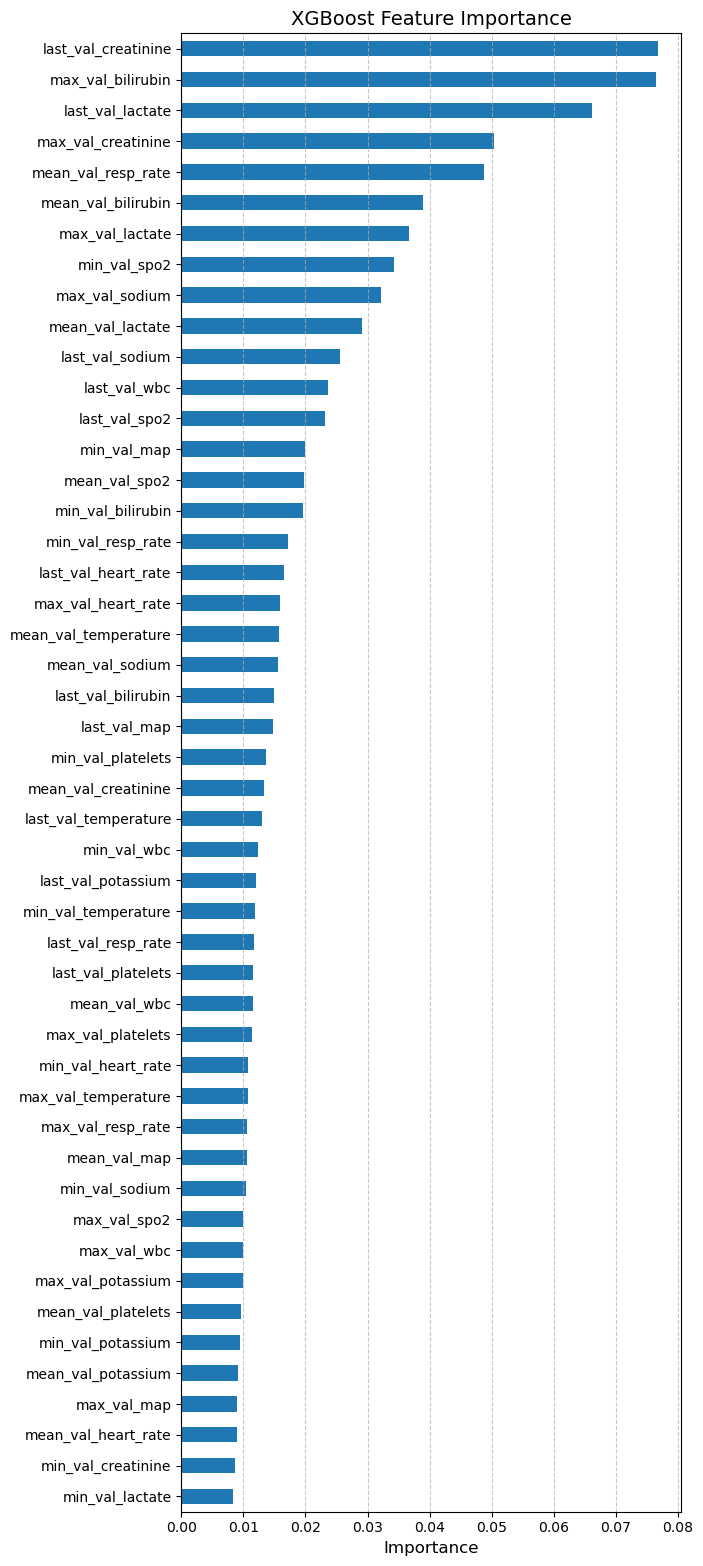

In [13]:
# Use XGBoost to select most important vital features + lab features (this step is to reduce redundancy ONLY -- demographic features are untouched):
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report
from xgboost import XGBClassifier

# Select vitals + lab features:
vitals_labs_cols = [col for col in bivariate_df.columns if any(x in col for x in [
    "heart_rate", "map", "resp_rate", "spo2", "temperature",
    "lactate", "creatinine", "bilirubin", "platelets",
    "potassium", "sodium", "wbc"
])]

# Set x and y (make sure y is int!!!):
X = bivariate_df[vitals_labs_cols].copy()
y = bivariate_df[target_col].copy()

y = y.astype(int)

# Train / Test Split:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y # Outcome is imbalanced.
)

# Train XGBoost (addressing class imbalance with weights):
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42,
    missing=float("nan"),
    scale_pos_weight=neg / pos # Penalize mistakes on the positive class more.
)

model.fit(X_train, y_train)

# Evaluate:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print(f"Test AUC: {auc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# Display feature importance:
importances = pd.Series(model.feature_importances_, index=vitals_labs_cols)
importances = importances.sort_values(ascending=False)

print("\nFeature importances:")
print(importances)

# Plot: 
importances_sorted = importances.sort_values()
n_features = len(importances_sorted)
fig_height = max(6, n_features * 0.4)
fig, ax = plt.subplots(figsize=(10, fig_height))
importances_sorted.plot(kind="barh", ax=ax)
ax.set_title("XGBoost Feature Importance", fontsize=14)
ax.set_xlabel("Importance", fontsize=12)
ax.tick_params(axis='y', labelsize=10)
plt.subplots_adjust(left=0.4)
ax.grid(axis="x", linestyle="--", alpha=0.7)
plt.show()

**NOTE:**

**Feature Importance:** Usually found in tree-based models, this feature represents how often a feature is used in splits.

**SHAP:** Can be applied to all models, but works best for tree-based models. This represents the impact of each feature when making decisions (i.e. "How much does a feature change the prediction by?").

**TLDR:** Feature importance IS NOT the same as SHAP / feature impact. We need to compare both to select the best vitals + labs!

/opt/miniconda3/envs/machinelearning/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


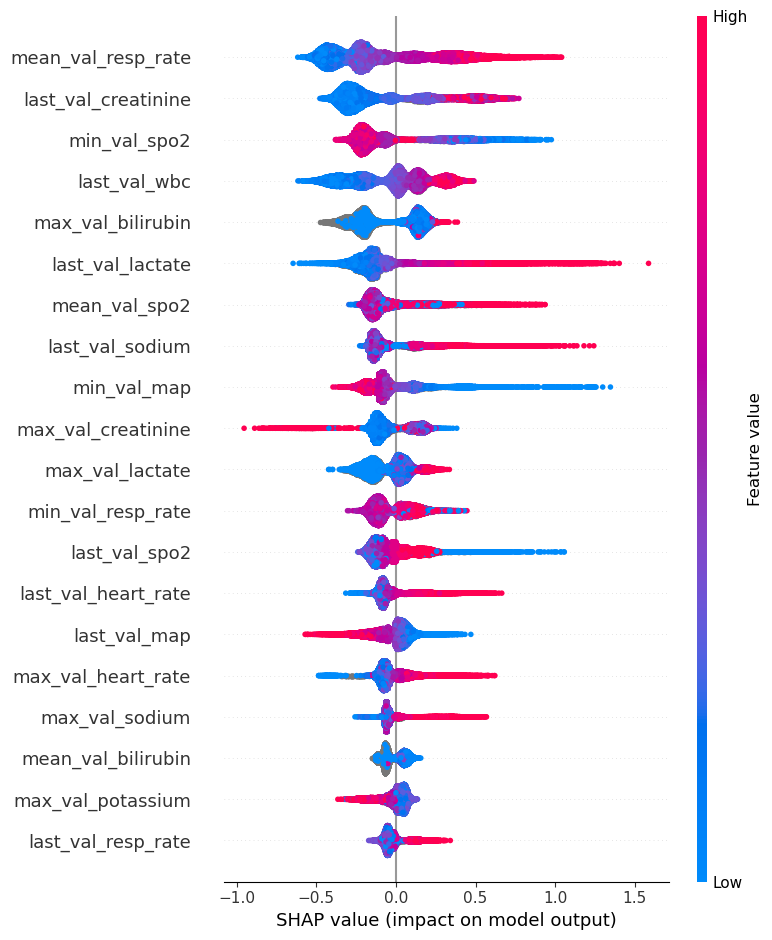

                 feature  mean_abs_shap
12    mean_val_resp_rate       0.297344
42   last_val_creatinine       0.277743
3           min_val_spo2       0.221712
47          last_val_wbc       0.195962
27     max_val_bilirubin       0.193532
43      last_val_lactate       0.189014
13         mean_val_spo2       0.143722
46       last_val_sodium       0.141164
1            min_val_map       0.132154
28    max_val_creatinine       0.117635
29       max_val_lactate       0.110365
2      min_val_resp_rate       0.106924
18         last_val_spo2       0.104081
15   last_val_heart_rate       0.095665
16          last_val_map       0.086375
5     max_val_heart_rate       0.077540
32        max_val_sodium       0.068030
34    mean_val_bilirubin       0.066381
31     max_val_potassium       0.056817
17    last_val_resp_rate       0.056033
0     min_val_heart_rate       0.054398
24     min_val_potassium       0.054177
30     max_val_platelets       0.050163
45    last_val_potassium       0.046578


In [14]:
# Examine SHAP values for XGBoost:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

shap.summary_plot(shap_values, X_train)

shap_importance = pd.DataFrame({
    "feature": X_train.columns,
    "mean_abs_shap": abs(shap_values).mean(axis=0)
    
}).sort_values("mean_abs_shap", ascending=False)

print(shap_importance)

When looking at the SHAP graph, we need to examine three components:

  1. **Separation:** Do the blue and red colors clearly separate on the left and right sides? If yes, then the feature is strong and useful.
  2. **Spread width:** Wide horizontal spreads indicate high impact features. If the spread is clustered near the center, then the feature is weak.
  3. **Consistency:** Red should mostly be on the right, blue should mostly be on the left (or vice versa). Consistent direction means reliable signal.

*Note that the SHAP graph is truncated -- it only displays top features.*

Based on the feature importance graph, SHAP graph, and a little bit of clinical knowledge, we'll select the following features from vitals + labs:

  - **Heart Rate:** last_val_heartrate + max_val_heartrate

  - **Temperature:** *DROPPING ENTIRELY*

  - **Respiratory Rate:** mean_val_resp_rate

  - **SpO2:** min_val_spo2

  - **MAP (Mean Arterial Pressure):** min_val_map

  - **Lactate:** last_val_lactate + max_val_lactate

  - **Creatinine:** last_val_creatinine

  - **WBC:** last_val_wbc

  - **Platelets:** min_val_platelets (select this over max_val_platelets b/c clinically, maximum platelet count isn't a good indicator of risk; we care more when platelets are low)

  - **Sodium:** last_val_sodium + max_val_sodium + min_val_sodium (sodium carries bidirectional risk)

  - **Potassium:** max_val_potassium + min_val_potassium (potassium carries bidirectional risk)

  - **Bilirubin:** max_val_bilirubin

In [15]:
# Choose reduced feature set:
selected_features = [
    # Static features:
    "first_careunit",
    "admission_type_grouped",
    "admission_location_grouped",
    "insurance",
    "language_grouped",
    "marital_status",
    "race_grouped",
    "is_male",
    "age",

    # Vitals + Labs:
    "last_val_heart_rate",
    "max_val_heart_rate",
    "mean_val_resp_rate",
    "min_val_spo2",
    "min_val_map",
    "last_val_lactate",
    "max_val_lactate",
    "last_val_creatinine",
    "last_val_wbc",
    "min_val_platelets",
    "last_val_sodium",
    "max_val_sodium",
    "min_val_sodium",
    "max_val_potassium",
    "min_val_potassium",
    "max_val_bilirubin",
]

In [16]:
# Build the final modeling dataframe:
modeling_df = bivariate_df[selected_features + [target_col]].copy()

In [21]:
# Separate X and y:
X = modeling_df.drop(columns=[target_col])
y = modeling_df[target_col].astype("int8")

print("\nSelected feature columns:")
print(X.columns.tolist())

print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nTarget distribution:")
print(y.value_counts(dropna=False))
print(y.value_counts(normalize=True, dropna=False))


Selected feature columns:
['first_careunit', 'admission_type_grouped', 'admission_location_grouped', 'insurance', 'language_grouped', 'marital_status', 'race_grouped', 'is_male', 'age', 'last_val_heart_rate', 'max_val_heart_rate', 'mean_val_resp_rate', 'min_val_spo2', 'min_val_map', 'last_val_lactate', 'max_val_lactate', 'last_val_creatinine', 'last_val_wbc', 'min_val_platelets', 'last_val_sodium', 'max_val_sodium', 'min_val_sodium', 'max_val_potassium', 'min_val_potassium', 'max_val_bilirubin']

Shape of X: (74583, 25)
Shape of y: (74583,)

Target distribution:
ICU_mortality
0    69200
1     5383
Name: count, dtype: int64
ICU_mortality
0    0.927825
1    0.072175
Name: proportion, dtype: float64


In [22]:
# Exporting the final modeling dataframe for training:
modeling_df.to_parquet("modeling_data.parquet", engine="pyarrow", index=False)